In [1]:
#Packages
import xarray as xr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Exploratory Data Analysis

**CMIP6 dataset**
- Variable: sea-ice thickness (sithick)
- Model: HadGEM3-GC31-MM
- Period: 2015–2029
- Source: ESGF

In [2]:
filepath = r'c:\Users\l.ruizlozano\Documents\Antartica-project\data\CMIP6\sithick_SImon_HadGEM3-GC31-MM_ssp585_r3i1p1f3_gn_201501-202912.nc'
ds = xr.open_dataset(filepath)

print(ds)

<xarray.Dataset> Size: 1GB
Dimensions:             (time: 180, bnds: 2, j: 1205, i: 1440, vertices: 4)
Coordinates:
  * time                (time) object 1kB 2015-01-16 00:00:00 ... 2029-12-16 ...
  * j                   (j) int32 5kB 0 1 2 3 4 5 ... 1200 1201 1202 1203 1204
  * i                   (i) int32 6kB 0 1 2 3 4 5 ... 1435 1436 1437 1438 1439
    latitude            (j, i) float32 7MB ...
    longitude           (j, i) float32 7MB ...
Dimensions without coordinates: bnds, vertices
Data variables:
    time_bnds           (time, bnds) object 3kB ...
    vertices_latitude   (j, i, vertices) float32 28MB ...
    vertices_longitude  (j, i, vertices) float32 28MB ...
    sithick             (time, j, i) float32 1GB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   59400.0
    branch_time_in_parent:  59400.0
    creation_date:          2020-05-04T08:04:27Z
    .

In [3]:
# Ross Sea: region of interest 
lat_min, lat_max = -76, -74
lon_min, lon_max = 174, 176

mask = (
        (ds["latitude"] >= lat_min) &
        (ds["latitude"] <= lat_max) &
        (ds["longitude"] >= lon_min) &
        (ds["longitude"] <= lon_max)
    )

sit = ds["sithick"]
sit_roi = sit.where(mask.compute(), drop=True)


In [4]:
# Set time
sit_roi = sit_roi.sel(time=slice("2015", "2026"))

In [5]:
df = sit_roi.to_dataframe().reset_index()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41472 entries, 0 to 41471
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       41472 non-null  object 
 1   j          41472 non-null  int32  
 2   i          41472 non-null  int32  
 3   latitude   41472 non-null  float32
 4   longitude  41472 non-null  float32
 5   sithick    36369 non-null  float32
dtypes: float32(3), int32(2), object(1)
memory usage: 1.1+ MB


In [7]:
df.isna().sum()

time            0
j               0
i               0
latitude        0
longitude       0
sithick      5103
dtype: int64

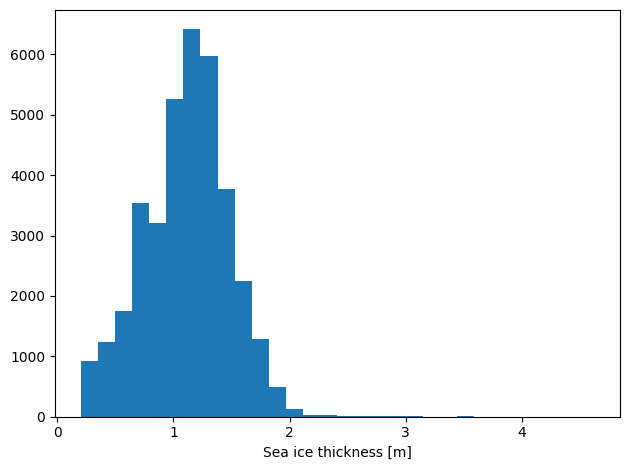

In [10]:
plt.figure()

plt.hist(df["sithick"], bins=30)
plt.xlabel("Sea ice thickness [m]")
plt.tight_layout()
plt.show()

## Pre-processing

- Add time columns and define aggregation for better visualisation in the next section

In [11]:
df = df.groupby(by="time")[["latitude", "longitude", "sithick"]].mean().reset_index()

In [12]:
df["year"] = df["time"].apply(lambda x: x.year)
df["month"] = df["time"].apply(lambda x: x.month)

In [13]:
df.head()

,time,latitude,longitude,sithick,year,month
0,2015-01-16 00:00:00,-75.031815,174.942825,0.987713,2015,1
1,2015-02-16 00:00:00,-75.031815,174.942825,0.737504,2015,2
2,2015-03-16 00:00:00,-75.031815,174.942825,0.663735,2015,3
3,2015-04-16 00:00:00,-75.031815,174.942825,0.895817,2015,4
4,2015-05-16 00:00:00,-75.031815,174.942825,0.948603,2015,5


In [14]:
df_annual = df.copy()
df_annual = df_annual.groupby(by="year")[["sithick"]].mean().reset_index()

## Sea-ice climatology and variability

In this section, we investigate: 
- monthly climatology
- annual variability

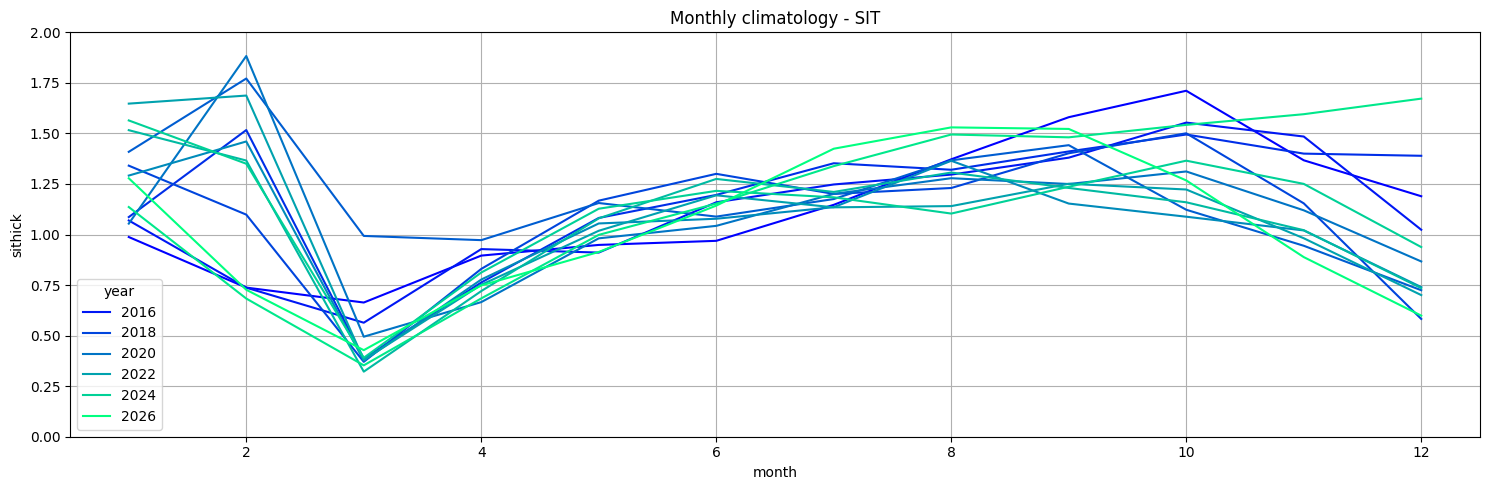

In [50]:
plt.figure(figsize=(15,5))
sns.lineplot(
    data=df,
    x='month',
    y='sithick',
    hue='year',
    palette='winter'
)

plt.title("Monthly climatology - SIT")
plt.ylim(0, 2), plt.xlim(0.5,12.5)
plt.grid(True)
plt.tight_layout()
plt.show()


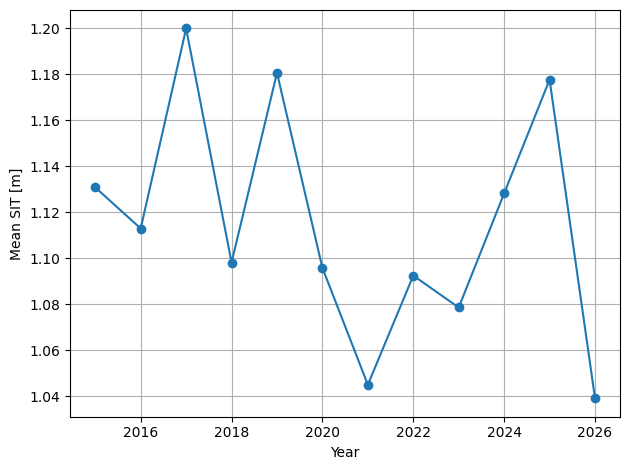

In [56]:
plt.figure()

plt.plot(df_annual.year,df_annual.sithick, '-o')
plt.xlabel("Year")
plt.ylabel("Mean SIT [m]")


# plt.ylim(0.3, 0.6)
plt.grid(True)
plt.tight_layout()
plt.show()

### SIT seasonal cycle statistics for the Antarctic Ross Sea
**CMIP6 predictions**
- Evaluation in Septembre (end of winter) and February (end of summer)

In [15]:
df.head()

,time,latitude,longitude,sithick,year,month
0,2015-01-16 00:00:00,-75.031815,174.942825,0.987713,2015,1
1,2015-02-16 00:00:00,-75.031815,174.942825,0.737504,2015,2
2,2015-03-16 00:00:00,-75.031815,174.942825,0.663735,2015,3
3,2015-04-16 00:00:00,-75.031815,174.942825,0.895817,2015,4
4,2015-05-16 00:00:00,-75.031815,174.942825,0.948603,2015,5


In [23]:
mask = (df.month == 2)
df_feb = df[mask]

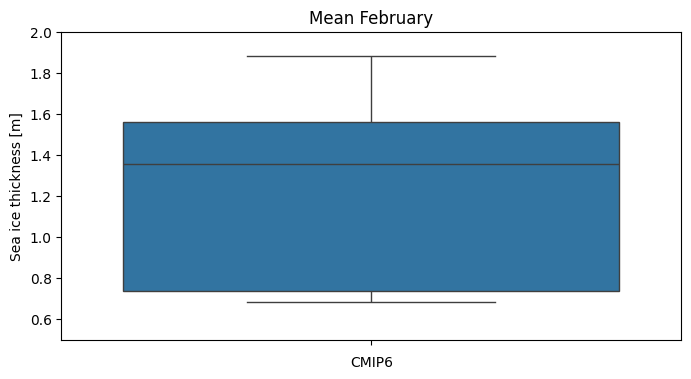

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(y='sithick', data=df_feb)
plt.title('Mean February')
plt.xlabel('CMIP6')
plt.ylabel('Sea ice thickness [m]')
plt.ylim([0.5,2])
plt.show()

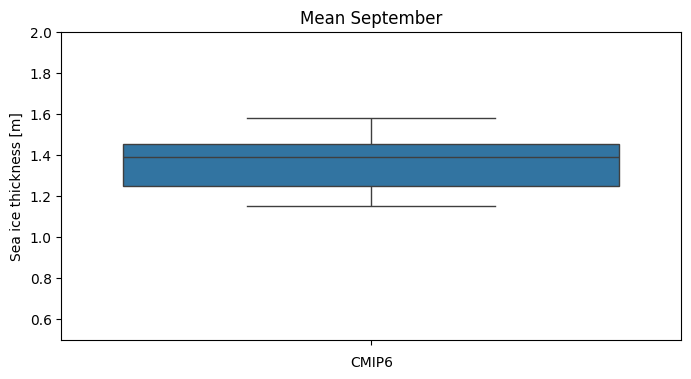

In [28]:
mask = (df.month == 9)
df_sep = df[mask]

plt.figure(figsize=(8, 4))
sns.boxplot(y='sithick', data=df_sep)
plt.title('Mean September')
plt.xlabel('CMIP6')
plt.ylabel('Sea ice thickness [m]')
plt.ylim([0.5,2])
plt.show()

## Quick discussion / key findings
- Strong seasonal variability: SIT varies substantially throughout the year, with a pronounced minimum around March and generally higher values later in the year.
- Large interannual variability: annual mean SIT ranges roughly from 1.04 to 1.20 m, with no clear monotonic trend over 2015–2026.
- Lowest annual SIT: around 2021 and 2026 (~1.04 m).
- Highest annual SIT: 2017 (~1.20 m), followed by 2019 (~1.18 m).
- Recent period: SIT increases from 2021 to 2025, then drops markedly in 2026.
- February: very large spread (~0.7–1.9 m), indicating strong interannual variability.
- September: much narrower distribution (~1.15–1.58 m), with a median around 1.4 m.

Important: the February–March behaviour is unusual -> due to the spatial averaging ? or the CMIP6 sithick data ? Need further analysis and drivers checking to understand this behaviour